In [1]:
import os
import re
import pandas as pd

# Replace this with your actual data directory
data_dir = r"EMGlabDatabaseWav\EMGlabDatabaseWav"
filenames = [f for f in os.listdir(data_dir) if f.startswith("N2001")]

def parse_filename(fname):
    """
    Parses EMGLab N2001 filenames like 'N2001A01BB02.wav'
    Returns subject ID, label, muscle, and recording ID
    """
    # Allow optional ".wav" at the end
    pattern = r"N2001([AMC])(\d+)([A-Z]{2})(\d+)(?:\.wav)?$"
    match = re.match(pattern, fname)
    if not match:
        return None

    label_code = match.group(1)
    subject_id = match.group(2)
    muscle = match.group(3)
    rec_id = int(match.group(4))

    label_map = {"A": "ALS", "M": "Myopathy", "C": "Normal"}

    return {
        "filename": fname,
        "subject": f"{label_code}{subject_id}",
        "label": label_map[label_code],
        "muscle": muscle,
        "rec_id": rec_id,
    }

# Parse all filenames
records = [parse_filename(f) for f in filenames]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)

# Preview the metadata table
print(df)

# ---- Added: subject count + subject names ----
subjects = sorted(df["subject"].unique())
print("\nNumber of subjects (unique people):", len(subjects))
print("Subjects:")
print(subjects)


             filename subject     label muscle  rec_id
0    N2001A01AP51.wav     A01       ALS     AP      51
1    N2001A01AP52.wav     A01       ALS     AP      52
2    N2001A01AP53.wav     A01       ALS     AP      53
3    N2001A01AP54.wav     A01       ALS     AP      54
4    N2001A01AP55.wav     A01       ALS     AP      55
..                ...     ...       ...    ...     ...
924  N2001M07VM15.wav     M07  Myopathy     VM      15
925  N2001M07VM16.wav     M07  Myopathy     VM      16
926  N2001M07VM17.wav     M07  Myopathy     VM      17
927  N2001M07VM18.wav     M07  Myopathy     VM      18
928  N2001M07VM19.wav     M07  Myopathy     VM      19

[929 rows x 5 columns]

Number of subjects (unique people): 25
Subjects:
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09', 'C10', 'M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07']


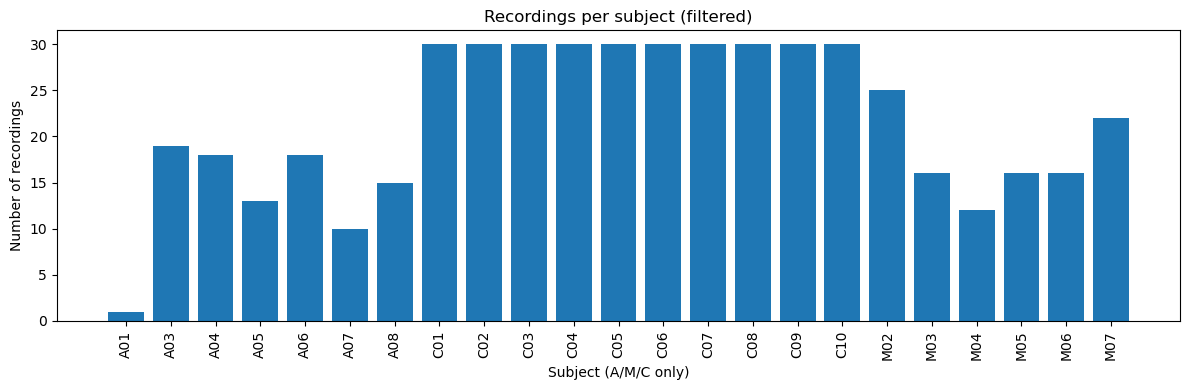

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

K = 5
ALLOWED_PREFIXES = ("A", "M", "C")
TEST_FRAC        = 0.10   # ~10% of subjects per prefix held out as test
TEST_RANDOM_STATE = 0     # seed for test split
CV_RANDOM_STATE   = 42    # seed for CV fold assignment

dfw = df.copy()
dfw["subject"] = dfw["subject"].astype(str)
dfw["prefix"]  = dfw["subject"].str[0]
dfw = dfw[dfw["prefix"].isin(ALLOWED_PREFIXES)].copy()

dfw = dfw[dfw["filename"].str.contains("BB", case=True, na=False)].copy()

# Counts per subject
counts = dfw.groupby("subject")["filename"].count().sort_index()


# Original plot (filtered)
plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.xlabel("Subject (A/M/C only)")
plt.ylabel("Number of recordings")
plt.title("Recordings per subject (filtered)")
plt.tight_layout()
plt.show()



=== Test split ===
  Test subjects : ['A07', 'C06', 'M05']
  Test rows     : 56  (11.2%)
  CV rows       : 445  (88.8%)


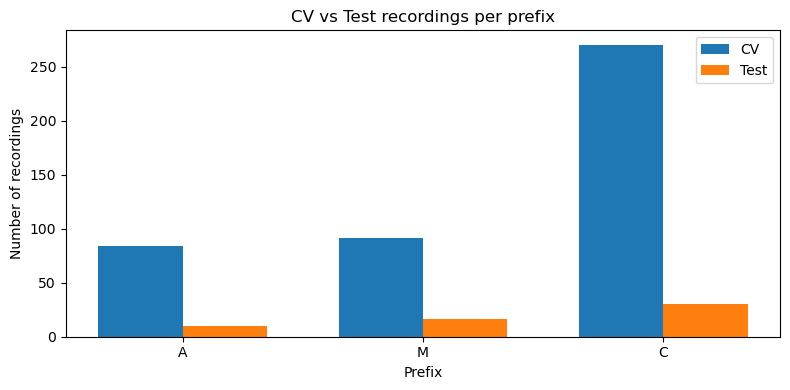

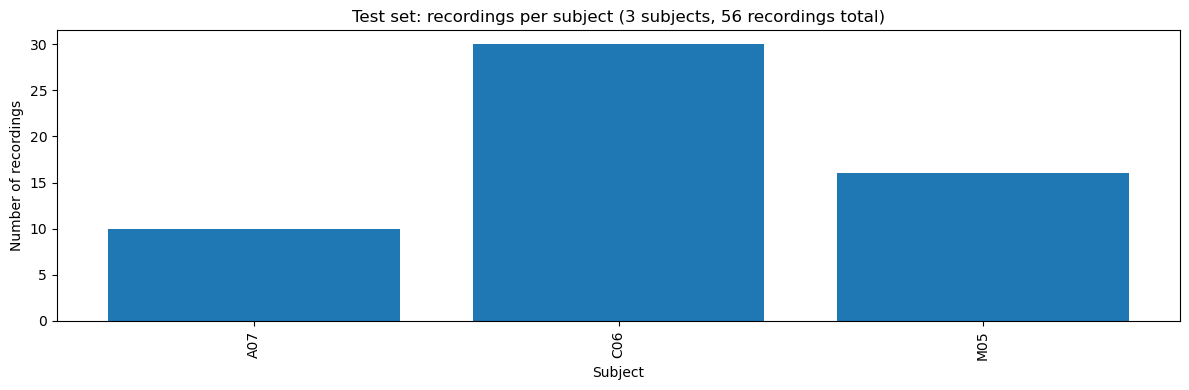

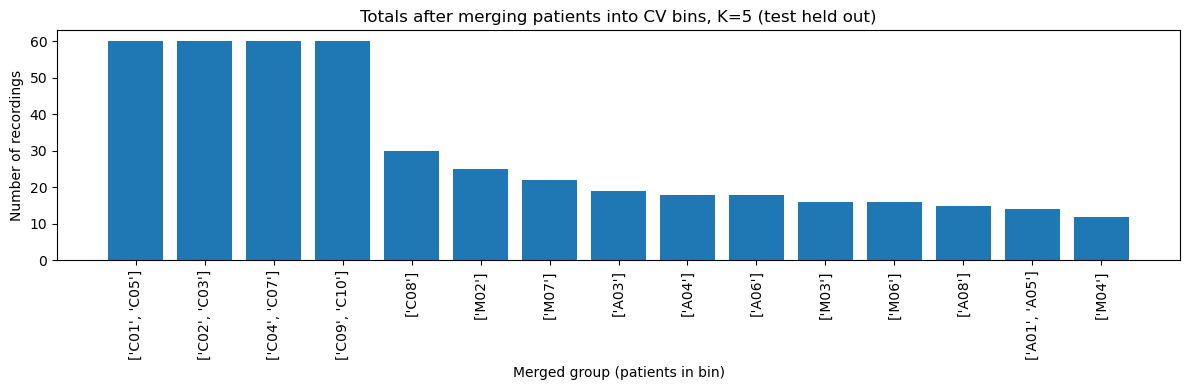

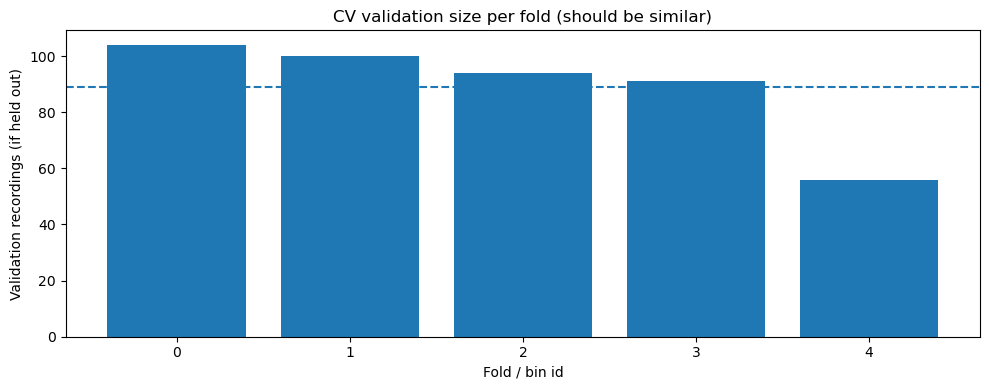

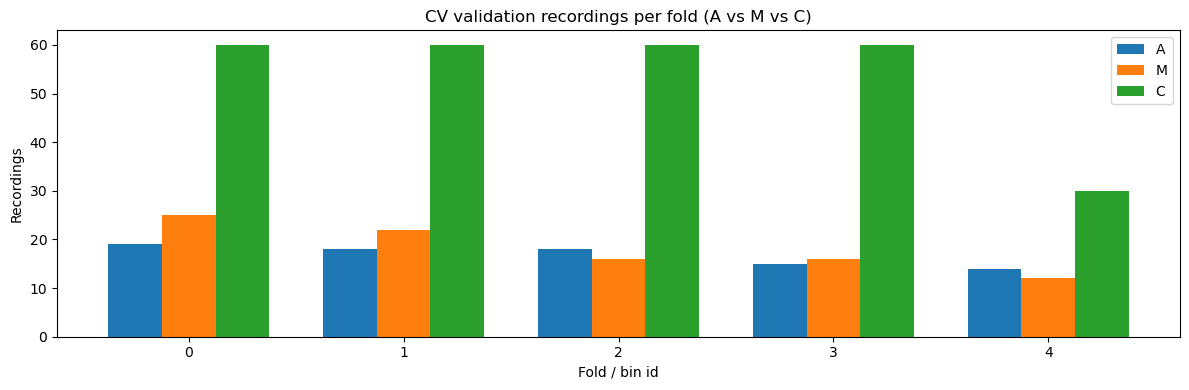

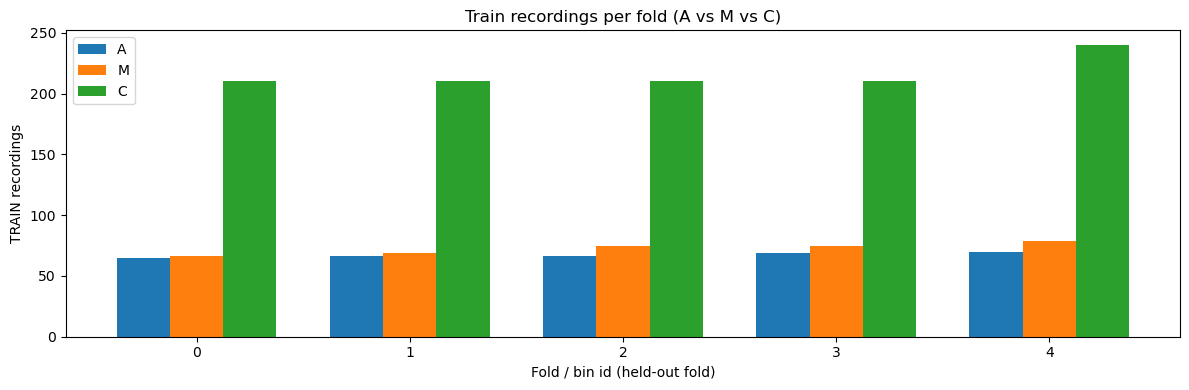

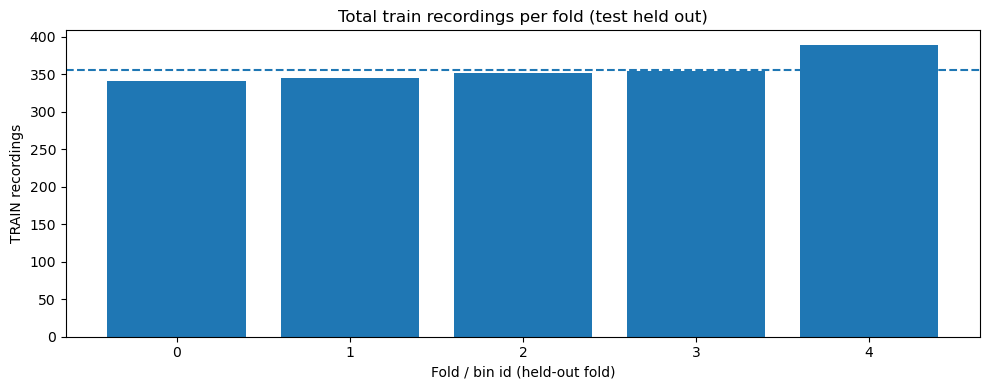


=== Test subjects per prefix ===
  A: ['A07'] -> 10 recordings
  M: ['M05'] -> 16 recordings
  C: ['C06'] -> 30 recordings

=== CV bin labels ===

Prefix A:
  fold 0: ['A03'] -> 19 recordings
  fold 1: ['A04'] -> 18 recordings
  fold 2: ['A06'] -> 18 recordings
  fold 3: ['A08'] -> 15 recordings
  fold 4: ['A01', 'A05'] -> 14 recordings

Prefix M:
  fold 0: ['M02'] -> 25 recordings
  fold 1: ['M07'] -> 22 recordings
  fold 2: ['M06'] -> 16 recordings
  fold 3: ['M03'] -> 16 recordings
  fold 4: ['M04'] -> 12 recordings

Prefix C:
  fold 0: ['C01', 'C05'] -> 60 recordings
  fold 1: ['C09', 'C10'] -> 60 recordings
  fold 2: ['C02', 'C03'] -> 60 recordings
  fold 3: ['C04', 'C07'] -> 60 recordings
  fold 4: ['C08'] -> 30 recordings

=== Fold summary (CV only, test excluded) ===
   fold  train_samples  val_samples val_bins
0     0            341          104      [0]
1     1            345          100      [1]
2     2            351           94      [2]
3     3            354           

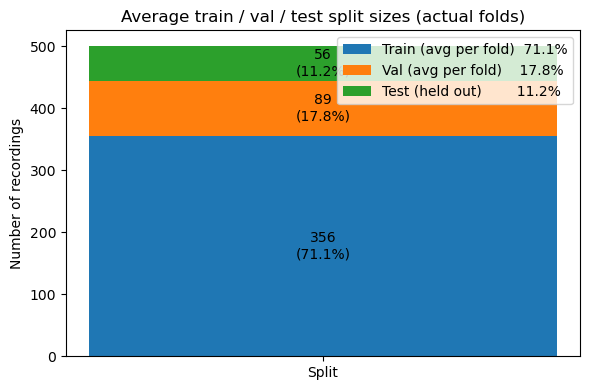

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

# =========================
# Config
# =========================
K = 5
ALLOWED_PREFIXES   = ("A", "M", "C")
TEST_FRAC          = 0.10   # ~10% of subjects per prefix held out as test
TEST_RANDOM_STATE  = 0      # seed for test split
CV_RANDOM_STATE    = 42     # seed for CV bin assignment

# =========================
# Helpers
# =========================
def greedy_balance_subjects(subject_counts: pd.Series, k: int, random_state: int = 0):
    """
    Assign subjects (with weights = #recordings) into k bins to balance totals.
    Greedy: largest subject goes to currently-lightest bin.
    Random tie-break for equal weights.
    """
    rng = np.random.default_rng(random_state)

    sc = subject_counts.sort_values(ascending=False)
    tmp = sc.reset_index()
    tmp.columns = ["subject", "n"]
    tmp["tie_rand"] = rng.random(len(tmp))
    tmp = tmp.sort_values(["n", "tie_rand"], ascending=[False, True])

    totals = np.zeros(k, dtype=int)
    subj2bin = {}

    for subj, n in zip(tmp["subject"], tmp["n"]):
        b = int(np.argmin(totals))
        subj2bin[subj] = b
        totals[b] += int(n)

    bin_totals = pd.Series(totals, index=list(range(k)), name="total_recordings")
    return subj2bin, bin_totals


# =========================
# 2) Stratified-by-prefix TEST split (by SUBJECTS)
# =========================
rng_test      = np.random.default_rng(TEST_RANDOM_STATE)
test_subjects = set()

for p in ALLOWED_PREFIXES:
    subjects_p = counts[counts.index.str.startswith(p)].index.tolist()
    if len(subjects_p) == 0:
        continue

    n_test = max(1, round(TEST_FRAC * len(subjects_p)))  # at least 1 per prefix if possible
    chosen = rng_test.choice(subjects_p, size=n_test, replace=False).tolist()
    test_subjects.update(chosen)

dfw["is_test"] = dfw["subject"].isin(test_subjects)
df_test = dfw[dfw["is_test"]].copy()
df_cv   = dfw[~dfw["is_test"]].copy()

print("\n=== Test split ===")
print(f"  Test subjects : {sorted(test_subjects)}")
print(f"  Test rows     : {len(df_test)}  ({100*len(df_test)/len(dfw):.1f}%)")
print(f"  CV rows       : {len(df_cv)}  ({100*len(df_cv)/len(dfw):.1f}%)")

# Visualise CV vs Test recordings per prefix
test_prefix_counts = df_test.groupby("prefix")["filename"].count().reindex(list(ALLOWED_PREFIXES), fill_value=0)
cv_prefix_counts   = df_cv.groupby("prefix")["filename"].count().reindex(list(ALLOWED_PREFIXES), fill_value=0)

plt.figure(figsize=(8, 4))
x = np.arange(len(ALLOWED_PREFIXES))
width = 0.35
plt.bar(x - width/2, cv_prefix_counts.values,   width=width, label="CV")
plt.bar(x + width/2, test_prefix_counts.values, width=width, label="Test")
plt.xticks(x, list(ALLOWED_PREFIXES))
plt.xlabel("Prefix")
plt.ylabel("Number of recordings")
plt.title("CV vs Test recordings per prefix")
plt.legend()
plt.tight_layout()
plt.show()

# Visualise: recordings per subject in TEST
test_subject_counts = df_test.groupby("subject")["filename"].count().sort_index()
plt.figure(figsize=(12, 4))
plt.bar(test_subject_counts.index, test_subject_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Subject")
plt.ylabel("Number of recordings")
plt.title(f"Test set: recordings per subject ({len(test_subject_counts)} subjects, {len(df_test)} recordings total)")
plt.tight_layout()
plt.show()

# =========================
# 3) Build balanced CV bins per prefix (ONLY on CV set)
# =========================
counts_cv = df_cv.groupby("subject")["filename"].count().sort_index()

subject_to_bin_key = {}
bin_key_to_label   = {}
bin_key_to_fold_id = {}
per_prefix_groups  = {}

for p in ALLOWED_PREFIXES:
    c_p = counts_cv[counts_cv.index.str.startswith(p)]
    if len(c_p) == 0:
        continue

    subj2bin, _ = greedy_balance_subjects(c_p, k=K, random_state=CV_RANDOM_STATE)
    per_prefix_groups[p] = {b: [] for b in range(K)}

    for subj, b in subj2bin.items():
        bin_key = f"{p}_bin{b}"
        subject_to_bin_key[subj] = bin_key
        bin_key_to_fold_id[bin_key] = b
        per_prefix_groups[p][b].append(subj)

    # stable printable label for each bin_key
    for b in range(K):
        members_sorted = sorted(per_prefix_groups[p][b])
        bin_key = f"{p}_bin{b}"
        bin_key_to_label[bin_key] = repr(members_sorted)

# Apply mappings to CV rows
df_cv = df_cv.copy()
df_cv["bin_key"] = df_cv["subject"].map(subject_to_bin_key)
if df_cv["bin_key"].isna().any():
    bad = df_cv.loc[df_cv["bin_key"].isna(), "subject"].unique().tolist()
    raise ValueError(f"Unmapped subjects found in CV set: {bad}")

df_cv["fold_id"]      = df_cv["bin_key"].map(bin_key_to_fold_id).astype(int)
df_cv["merged_group"] = df_cv["bin_key"].map(bin_key_to_label)

# =========================
# 4) Visualise CV bin balance (on CV set)
# =========================
merged_counts = df_cv.groupby("merged_group")["filename"].count().sort_values(ascending=False)
plt.figure(figsize=(12, 4))
plt.bar(merged_counts.index.astype(str), merged_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Merged group (patients in bin)")
plt.ylabel("Number of recordings")
plt.title(f"Totals after merging patients into CV bins, K={K} (test held out)")
plt.tight_layout()
plt.show()

fold_totals = df_cv.groupby("fold_id")["filename"].count().reindex(range(K), fill_value=0)
plt.figure(figsize=(10, 4))
plt.bar(fold_totals.index.astype(str), fold_totals.values)
plt.axhline(fold_totals.mean(), linestyle="--")
plt.xlabel("Fold / bin id")
plt.ylabel("Validation recordings (if held out)")
plt.title("CV validation size per fold (should be similar)")
plt.tight_layout()
plt.show()

prefix_fold = (
    df_cv.groupby(["prefix", "fold_id"])["filename"].count()
         .unstack(fill_value=0)
         .reindex(index=list(ALLOWED_PREFIXES), fill_value=0)
         .reindex(columns=range(K), fill_value=0)
)

plt.figure(figsize=(12, 4))
x = np.arange(K)
width = 0.25
for i, p in enumerate(ALLOWED_PREFIXES):
    if p in prefix_fold.index:
        plt.bar(x + (i-1)*width, prefix_fold.loc[p].values, width=width, label=p)
plt.xticks(x, [str(i) for i in range(K)])
plt.xlabel("Fold / bin id")
plt.ylabel("Recordings")
plt.title("CV validation recordings per fold (A vs M vs C)")
plt.tight_layout()
plt.legend()
plt.show()

prefix_total_cv = df_cv.groupby("prefix")["filename"].count().reindex(list(ALLOWED_PREFIXES), fill_value=0)
train_prefix_fold = prefix_fold.copy()
for p in train_prefix_fold.index:
    train_prefix_fold.loc[p] = prefix_total_cv.loc[p] - prefix_fold.loc[p]

plt.figure(figsize=(12, 4))
for i, p in enumerate(ALLOWED_PREFIXES):
    if p in train_prefix_fold.index:
        plt.bar(x + (i-1)*width, train_prefix_fold.loc[p].values, width=width, label=p)
plt.xticks(x, [str(i) for i in range(K)])
plt.xlabel("Fold / bin id (held-out fold)")
plt.ylabel("TRAIN recordings")
plt.title("Train recordings per fold (A vs M vs C)")
plt.tight_layout()
plt.legend()
plt.show()

train_totals = df_cv.shape[0] - fold_totals
plt.figure(figsize=(10, 4))
plt.bar(train_totals.index.astype(str), train_totals.values)
plt.axhline(train_totals.mean(), linestyle="--")
plt.xlabel("Fold / bin id (held-out fold)")
plt.ylabel("TRAIN recordings")
plt.title("Total train recordings per fold (test held out)")
plt.tight_layout()
plt.show()

# =========================
# 5) Print test subjects + CV bins composition
# =========================
print("\n=== Test subjects per prefix ===")
for p in ALLOWED_PREFIXES:
    ts = sorted(s for s in test_subjects if s.startswith(p))
    total = int(counts.reindex(ts).fillna(0).sum())
    print(f"  {p}: {ts} -> {total} recordings")

print("\n=== CV bin labels ===")
for p in ALLOWED_PREFIXES:
    if p not in per_prefix_groups:
        continue
    print(f"\nPrefix {p}:")
    for b in range(K):
        members = sorted(per_prefix_groups[p][b])
        total   = int(counts_cv.reindex(members).fillna(0).sum())
        print(f"  fold {b}: {repr(members)} -> {total} recordings")

# =========================
# 6) K-fold split on CV set (GroupKFold) + fold summary
# =========================
gkf        = GroupKFold(n_splits=K)
X_cv       = df_cv.index.to_numpy()
groups_arr = df_cv["fold_id"].to_numpy()

fold_summary = []
train_sizes = []
val_sizes   = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_cv, groups=groups_arr), start=0):
    train_sizes.append(len(train_idx))
    val_sizes.append(len(val_idx))
    fold_summary.append({
        "fold":          fold,
        "train_samples": len(train_idx),
        "val_samples":   len(val_idx),
        "val_bins":      sorted(df_cv.iloc[val_idx]["fold_id"].unique().tolist()),
        "val_bins_labels": sorted(df_cv.iloc[val_idx]["merged_group"].unique().tolist()),
    })

fold_summary_df = pd.DataFrame(fold_summary)

print("\n=== Fold summary (CV only, test excluded) ===")
print(fold_summary_df[["fold", "train_samples", "val_samples", "val_bins"]])
for _, r in fold_summary_df.iterrows():
    print(f"fold {int(r['fold'])} holds out bins: {r['val_bins_labels']}")

# =========================
# 7) Accurate "Average train / val / test split sizes" + percentages
# =========================
train_sizes = np.array(train_sizes, dtype=float)
val_sizes   = np.array(val_sizes,   dtype=float)

avg_train = train_sizes.mean()
avg_val   = val_sizes.mean()
test_size = float(len(df_test))

total_all = avg_train + avg_val + test_size  # ~ len(dfw)

pct_train = 100.0 * avg_train / total_all if total_all else 0.0
pct_val   = 100.0 * avg_val   / total_all if total_all else 0.0
pct_test  = 100.0 * test_size / total_all if total_all else 0.0

plt.figure(figsize=(6, 4))

b1 = plt.bar(["Split"], [avg_train],
             label=f"Train (avg per fold)  {pct_train:.1f}%")
b2 = plt.bar(["Split"], [avg_val], bottom=[avg_train],
             label=f"Val (avg per fold)    {pct_val:.1f}%")
b3 = plt.bar(["Split"], [test_size], bottom=[avg_train + avg_val],
             label=f"Test (held out)        {pct_test:.1f}%")

plt.ylabel("Number of recordings")
plt.title("Average train / val / test split sizes (actual folds)")

# ---- add percentage (and count) labels inside each segment ----
x_center = b1[0].get_x() + b1[0].get_width() / 2

def annotate_segment(bottom, height, pct):
    if height <= 0:
        return
    y = bottom + height / 2
    plt.text(
        x_center, y,
        f"{height:.0f}\n({pct:.1f}%)",
        ha="center", va="center"
    )

annotate_segment(0,                avg_train, pct_train)
annotate_segment(avg_train,        avg_val,   pct_val)
annotate_segment(avg_train+avg_val, test_size, pct_test)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()